This file implements one execution strategy:
$$
\texttt{regime\_fixed}
$$

The purpose of this strategy is to simulate how an agent executes required position changes using a **regime-conditional fixed limit order rule**.

The agent already has a target position at each 5-minute timestamp. Therefore, this strategy does **not** decide what position to hold. Instead, it answers the execution question:
$$
\text{Given that I need to trade, what limit price should I use?}
$$

# **1. Trading Problem**

At every 5-minute timestamp, the agent observes a required net position:
$$
q_t
$$

The actual order size is the change in position:

$$
\Delta q_t = q_t - q_{t-1}
$$

If:

$$
\Delta q_t > 0
$$

the agent needs to buy.

If:

$$
\Delta q_t < 0
$$

the agent needs to sell.

If:

$$
\Delta q_t = 0
$$

there is no trade.

```{mermaid}
flowchart TD
    A["Required position q_t"] --> B["Position change Δq_t = q_t - q_{t-1}"]
    B --> C{"Direction?"}
    C -->|Δq_t > 0| D["Buy order"]
    C -->|Δq_t < 0| E["Sell order"]
    C -->|Δq_t = 0| F["No trade"]
```

This file is not trying to forecast the agent's future target position. The required position is already given. The file only studies how to execute the required position change.

# **2. Why Use Limit Orders?**

The benchmark execution rule is immediate execution at the current close price.

However, instead of trading immediately, the strategy tries to obtain price improvement using a limit order.

For a buy order, the agent wants to buy below the current close:

$$
P_{\text{target}} = P_t - k \cdot \text{tick size}
$$

For a sell order, the agent wants to sell above the current close:

$$
P_{\text{target}} = P_t + k \cdot \text{tick size}
$$

Here, $k$ is the number of ticks away from the current close.

A larger $k$ gives a better execution price if filled, but a lower probability of being filled.

A smaller $k$ gives a higher probability of being filled, but less price improvement.

```{mermaid}
flowchart TD
    A["Choose limit distance k"] --> B{"Increase or decrease k?"}

    B -->|Larger k| C["Better execution price if filled"]
    C --> D["Lower fill probability"]

    B -->|Smaller k| E["Less price improvement"]
    E --> F["Higher fill probability"]
```

So the key problem is choosing $k$.

# **3. Empirical Future Move Distribution**

The strategy chooses $k$ using historical price movement.

At each historical timestamp $t$, the file looks forward over the next $\tau$-minute window.

For a buy order, the relevant future move is:

$$
\text{future\_low\_move}_t
=
P_t - \min_{s \in (t, t+\tau]} L_s
$$

This measures how far the price dropped after time $t$.

For a sell order, the relevant future move is:

$$
\text{future\_high\_move}_t
=
\max_{s \in (t, t+\tau]} H_s - P_t
$$

This measures how far the price rose after time $t$.

Therefore, the empirical fill probability for a limit order $k$ ticks away is:

$$
\Pr
\left(
\text{favorable move}
\ge
k \cdot \text{tick size}
\right)
$$

For buys, the favorable move is a downward move.

For sells, the favorable move is an upward move.

The intuition is:

For a buy order, we care about how far the price falls after the current close.

```{mermaid}
flowchart TD
    A["Buy order"] --> B["Current close P_t"]
    B --> C["Look forward over the next τ minutes"]
    C --> D["Find the minimum low price"]
    D --> E["Measure how far price dropped"]
    E --> F["future_low_move = P_t - future minimum low"]
```

For a sell order, we care about how far the price rises after the current close.

```{mermaid}
flowchart TD
    A["Sell order"] --> B["Current close P_t"]
    B --> C["Look forward over the next τ minutes"]
    C --> D["Find the maximum high price"]
    D --> E["Measure how far price rose"]
    E --> F["future_high_move = future maximum high - P_t"]
```

# **4. Why Condition on Market State?**

A global historical distribution treats all market environments the same.

But execution behavior should depend on the current market state.

For example, in a high-volatility regime, prices tend to move farther, so a farther limit order may still get filled.

In a strong trend regime, upward and downward filling probabilities may become asymmetric.

Therefore, this strategy conditions the empirical distribution on two state variables:

$$
\text{state}_t
=
(\text{volatility regime}_t,\ \text{trend regime}_t)
$$

Instead of estimating:

$$
\Pr
\left(
\text{favorable move}
\ge
k \cdot \text{tick size}
\right)
$$

the strategy estimates:

$$
\Pr
\left(
\text{favorable move}
\ge
k \cdot \text{tick size}
\mid
\text{volatility regime},\ \text{trend regime}
\right)
$$

So the strategy does not ask:

$$
\text{How far does the market usually move?}
$$

It asks:

$$
\text{How far does the market usually move when the current volatility-trend state looks like this?}
$$

# **5. Volatility State Variable**

The volatility feature is built from 1-minute returns.

The 1-minute log return is:

$$
r_t = \log P_t - \log P_{t-1}
$$

Over a $begin:math:text$\\tau$end:math:text$-minute window, realized variance is:

$$
RV_t = \sum_{i=t-\tau+1}^{t} r_i^2
$$

Realized volatility is:

$$
\sigma_t = \sqrt{RV_t}
$$

Then the raw realized volatility is smoothed using an EMA:

$$
V_t = \text{EMA}(\sigma_t)
$$

This becomes the volatility state variable:

$$
V_t = \texttt{ema\_volatility\_t}
$$

The construction is:

```{mermaid}

flowchart TD

    A["1-min close prices"] --> B["1-min log returns"]

    B --> C["τ-minute realized volatility"]

    C --> D["EMA smoothing"]

    D --> E["Volatility state"]

```

High volatility means the price tends to move more within the execution window. Therefore, in a high-volatility regime, the strategy may choose a farther limit price while still keeping a reasonable fill probability.

# **6. Trend State Variable**

The trend feature is based on the difference between a short price EMA and a long price EMA.

The trend variable is:

$$
\text{trend}_t
=
\frac{
\text{EMA}_{\text{short}}(P_t)
-
\text{EMA}_{\text{long}}(P_t)
}{
P_t
}
\times 100
$$

In the code, this is stored as:

$$
\texttt{ema\_price\_diff\_pct}
$$

If the short EMA is above the long EMA, the trend variable is positive.

If the short EMA is below the long EMA, the trend variable is negative.

The construction is:

```{mermaid}
flowchart TD
    A["5-min close price"] --> B["short EMA"]
    A --> C["long EMA"]

    B --> D["Compare short EMA and long EMA"]
    C --> D

    D --> E["Normalized EMA difference"]
    E --> F["Trend state"]
```

Volatility measures how much the price tends to move.

Trend measures the directional condition of the market.

Together, they define the market regime.

# **7. Two-Dimensional Regime Definition**

The file divides volatility and trend into quantile buckets.

For example, if:

$$
n_{\text{vol}} = 3
$$

and:

$$
n_{\text{trend}} = 3
$$

then there are:

$$
3 \times 3 = 9
$$

regimes.

The regime grid is:

```{mermaid}
flowchart TD

    A["Market state"] --> B["Volatility regime"]
    A --> C["Trend regime"]

    B --> B0["vol_0"]
    B --> B1["vol_1"]
    B --> B2["vol_2"]

    C --> C0["trend_0"]
    C --> C1["trend_1"]
    C --> C2["trend_2"]

    B0 --> R00["vol0, tr0"]
    B0 --> R01["vol0, tr1"]
    B0 --> R02["vol0, tr2"]

    B1 --> R10["vol1, tr0"]
    B1 --> R11["vol1, tr1"]
    B1 --> R12["vol1, tr2"]

    B2 --> R20["vol2, tr0"]
    B2 --> R21["vol2, tr1"]
    B2 --> R22["vol2, tr2"]

    C0 --> R00
    C1 --> R01
    C2 --> R02

    C0 --> R10
    C1 --> R11
    C2 --> R12

    C0 --> R20
    C1 --> R21
    C2 --> R22
```

Each historical timestamp belongs to one volatility-trend state.

For example:

$$
\texttt{vol\_0\_trend\_2}
$$

means low volatility and high positive trend.

And:

$$
\texttt{vol\_2\_trend\_0}
$$

means high volatility and low or negative trend.

So the conditional distribution is not one distribution for all times. It is a collection of distributions, one for each market state.

```{mermaid}
flowchart TD
    A["All historical samples"] --> B["Split by volatility regime"]
    B --> C["Split by trend regime"]
    C --> D["State-specific empirical distributions"]
```

# **8. Choosing the Limit Distance**

When a new order arrives, the strategy first identifies the current state:

$$
\text{state}_t
=
(\text{vol regime}_t,\ \text{trend regime}_t)
$$

Then it selects historical observations from the same state.

For a buy order, it uses the conditional distribution of:

$$
\text{future\_low\_move}
$$

For a sell order, it uses the conditional distribution of:

$$
\text{future\_high\_move}
$$

For each candidate $begin:math:text$k$end:math:text$, the strategy estimates:

$$
\widehat p(k)
=
\Pr
\left(
\text{favorable move}
\ge
k \cdot \text{tick size}
\mid
\text{state}_t
\right)
$$

Then it chooses the largest $begin:math:text$k$end:math:text$ such that:

$$
\widehat p(k) \ge \text{fill probability target}
$$

For example, if:

$$
\text{fill probability target} = 0.9
$$

the selected $begin:math:text$k$end:math:text$ should historically have been reached at least 90% of the time under the same volatility-trend state.

The decision flow is:

```{mermaid}
flowchart TD
    A["Current order"] --> B["Observe volatility-trend state"]
    B --> C["Select historical samples from the same state"]
    C --> D["Estimate fill probability for k = 0, 1, 2, ..."]
    D --> E["Choose largest k satisfying target fill probability"]
    E --> F["Convert k into target price"]
```

# **9. Target Price Construction**

Once $begin:math:text$k$end:math:text$ is chosen, the strategy converts it into a target price.

For a buy order:

$$
P_{\text{target}}
=
P_t - k \cdot \text{tick size}
$$

For a sell order:

$$
P_{\text{target}}
=
P_t + k \cdot \text{tick size}
$$

If $begin:math:text$k\=0$end:math:text$, the order is effectively executed immediately at the current close.

If $begin:math:text$k\>0$end:math:text$, the strategy places a limit order away from the current close.

A buy example:

$$
P_t = 100.00
$$

$$
k = 2
$$

$$
\text{tick size} = 0.25
$$

Then:

$$
P_{\text{target}}
=
100.00 - 2 \times 0.25
=
99.50
$$

A sell example:

$$
P_t = 100.00
$$

$$
k = 3
$$

$$
\text{tick size} = 0.25
$$

Then:

$$
P_{\text{target}}
=
100.00 + 3 \times 0.25
=
100.75
$$

# **10. Fixed Target Execution Rule**

This is the core simplification of the current file.

Once the target price is chosen, the strategy does **not** reset the target.

It does **not** recompute a new limit price after $begin:math:text$\\tau$end:math:text$.

It does **not** cancel the order after one window.

Instead, the order waits until the target price is reached.

```{mermaid}
flowchart TD
    A["Order arrives"] --> B["Choose target price once"]
    B --> C["Keep target price fixed"]
    C --> D["Scan future market prices"]

    D --> E{"Target reached?"}

    E -->|Yes| F["Execute at target price"]
    E -->|No| G["Execute at final close"]
```

For a buy order, the limit order is filled if:

$$
L_s \le P_{\text{target}}
$$

For a sell order, the limit order is filled if:

$$
H_s \ge P_{\text{target}}
$$

If the condition is reached, the execution price is:

$$
P_{\text{exec}} = P_{\text{target}}
$$

If the target is never reached before the end of the sample, the order is force-executed at the last close:

$$
P_{\text{exec}} = P_{\text{final close}}
$$

This rule is called fixed because the target price is fixed after order placement.

# **11. Look-Ahead Bias Control**

The strategy updates the empirical distribution online.

A historical observation at time $u$ cannot be used immediately, because its future $\tau$-minute move is not known until $u+\tau$.

Therefore, the sample generated at time $u$ becomes available only when:

$$
u + \tau \le t
$$

At backtest time $t$, the strategy only uses samples whose forward windows have already completed.

```{mermaid}
flowchart TD
    A["Timestamp u"] --> B["Future window: (u, u + τ]"]
    B --> C["Future move becomes known at u + τ"]
    C --> D["Sample can be added to distribution"]
```

This prevents the strategy from using future information.

Without this constraint, the strategy would be using information that would not have been known at the decision time.

# **12. Fallback Distribution**

Some volatility-trend regimes may have too few historical observations.

If the number of observations in the current state is below:

$$
\texttt{min\_obs\_per\_regime}
$$

then the strategy does not trust the conditional distribution.

Instead, it falls back to the global historical distribution.

```{mermaid}
flowchart TD
    A["Current regime distribution"] --> B{"Enough observations?"}

    B -->|Yes| C["Use regime-conditional distribution"]
    B -->|No| D["Use global fallback distribution"]
```

This makes the rule more stable when the regime is rare.

So the rule is regime-conditional when enough data exists, but robust when the state is too sparse.

# **13. Execution Output**

The function returns two objects:

$$
\texttt{pnl\_df},\ \texttt{exec\_df}
$$

The first output is:

$$
\texttt{pnl\_df}
$$

This records the PnL path through time.

It usually contains:

```{mermaid}
flowchart TD
    A["PnL record"] --> B["time"]
    A --> C["cash_flow"]
    A --> D["cash"]
    A --> E["position"]
    A --> F["pnl"]
```

The second output is:

$$
\texttt{exec\_df}
$$

This records order-level execution details.

It usually contains:

```{mermaid}
flowchart TD
    A["Execution record"] --> B["signal_time"]
    A --> C["exec_time"]
    A --> D["side"]
    A --> E["qty"]
    A --> F["delta_q"]
    A --> G["target_price"]
    A --> H["exec_price"]
    A --> I["fill_type"]
    A --> J["chosen_k"]
    A --> K["state_key"]
```

The variable `fill_type` can be:

```{mermaid}
flowchart TD
    A["fill_type"] --> B["market"]
    A --> C["limit"]
    A --> D["forced_close"]

    B --> B1["k = 0"]
    B1 --> B2["Order is executed immediately"]

    C --> C1["Target price was reached"]
    C1 --> C2["Execute at target price"]

    D --> D1["Target price was never reached"]
    D1 --> D2["Execute at final close"]
```

# **14. PnL Accounting**

For each execution, the cash flow is:

$$
\text{cash flow}_t
=
-\Delta q_t \cdot P_{\text{exec},t}
$$

If the strategy buys, $\Delta q_t > 0$, so cash decreases.

If the strategy sells, $\Delta q_t < 0$, so cash increases.

Cumulative cash is:

$$
\text{cash}_t
=
\sum_{s \le t}
\text{cash flow}_s
$$

The marked-to-market PnL is:

$$
\text{PnL}_t
=
\text{cash}_t
+
\text{position}_t \cdot P_t
$$

So the PnL combines realized cash flow and current inventory value.

The accounting logic is:

```{mermaid}
flowchart TD
    A["Execution price"] --> B["Cash flow"]
    B --> C["Cumulative cash"]
    C --> D["Cash + marked inventory value"]
    D --> E["PnL"]
```

# **15. Full Workflow**

The full workflow of the file is:

```{mermaid}
flowchart TD
    A["Raw futures data"] --> B["Compute volatility feature"]
    B --> C["Compute trend feature"]
    C --> D["Assign volatility-trend regime"]
    D --> E["Build historical future move distributions"]
    E --> F["Update distributions online"]
    F --> G["Read agent position changes"]
    G --> H["Generate buy/sell orders"]
    H --> I["Choose regime-conditional limit distance"]
    I --> J["Place fixed target order"]
    J --> K["Wait until filled or final close"]
    K --> L["Record execution"]
    L --> M["Compute PnL"]
```

A compact view is:

```{mermaid}
flowchart TD
    A["Market data"] --> B["Volatility state"]
    A --> C["Trend state"]
    A --> D["Conditional future move distribution"]

    E["Agent position path"] --> F["Position change orders"]

    B --> G["Regime-conditional fixed limit order"]
    C --> G
    D --> G
    F --> G

    G --> H["Execution details + PnL"]
```

# **16. Interpretation**

This file does not test whether the agent's signal is profitable.

The agent's target position is taken as given.

The file tests whether execution can be improved by replacing immediate execution with a regime-conditional limit order rule.

The research question is:

$$
\text{Can volatility and trend help us choose better limit order prices?}
$$

More specifically, the strategy asks:

$$
\text{Given the current volatility-trend state, how far can I place my limit order while maintaining a target fill probability?}
$$



This file only studies the execution problem.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))
from src.utils.paths import RAW_DATA_DIR, DATA_DIR
from src.trade.regime_fixed_rule import regime_fixed

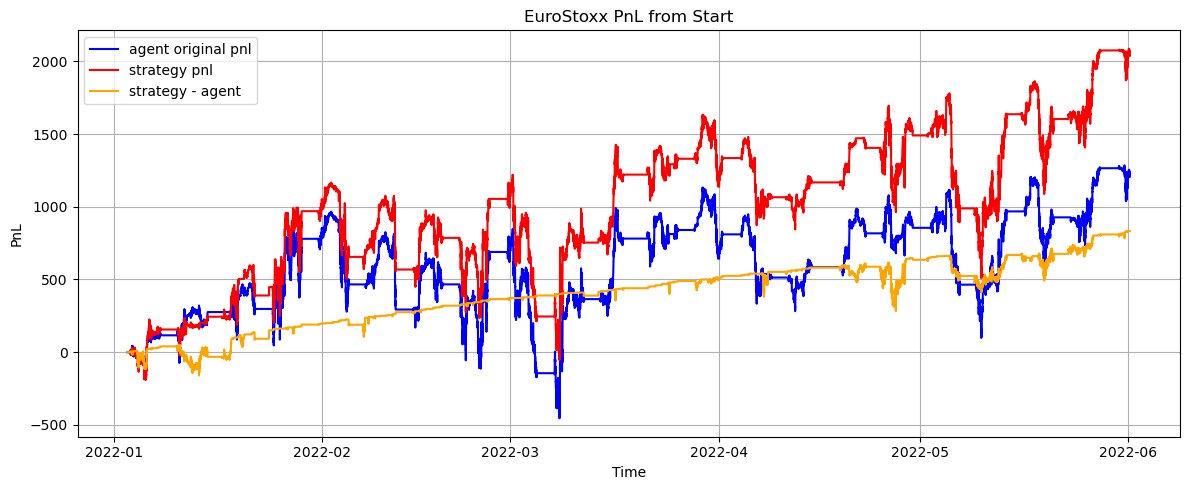

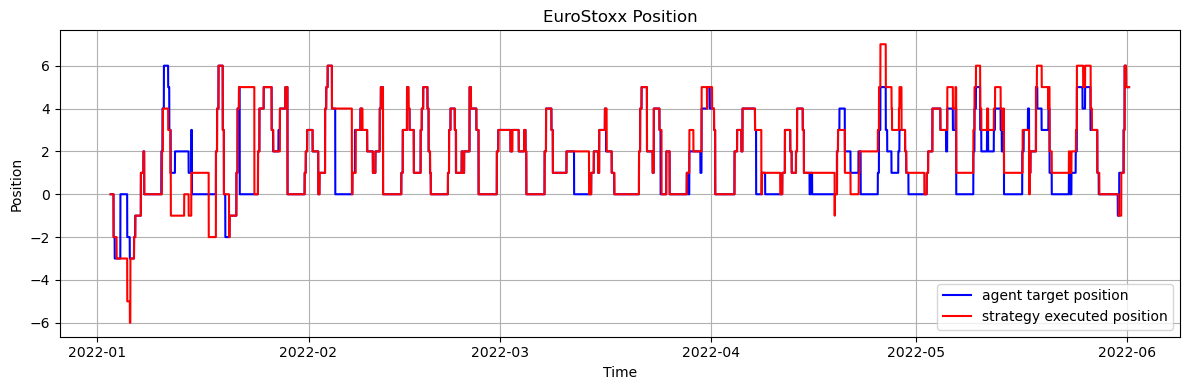


===== EuroStoxx Summary =====
Final agent PnL:     1219.5
Final strategy PnL:  2052.0
Final PnL diff:      832.5
Final PnL improve    68.27%

Execution state counts:
execution_state
successful           169
delayed_execution     43
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution     302.302326            25.674419
successful              2.147929             1.000000


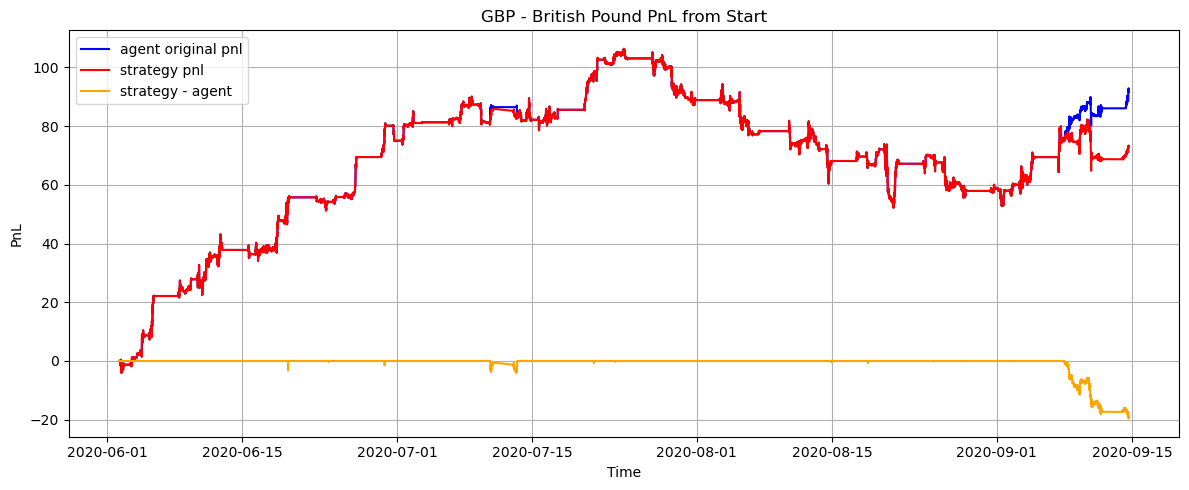

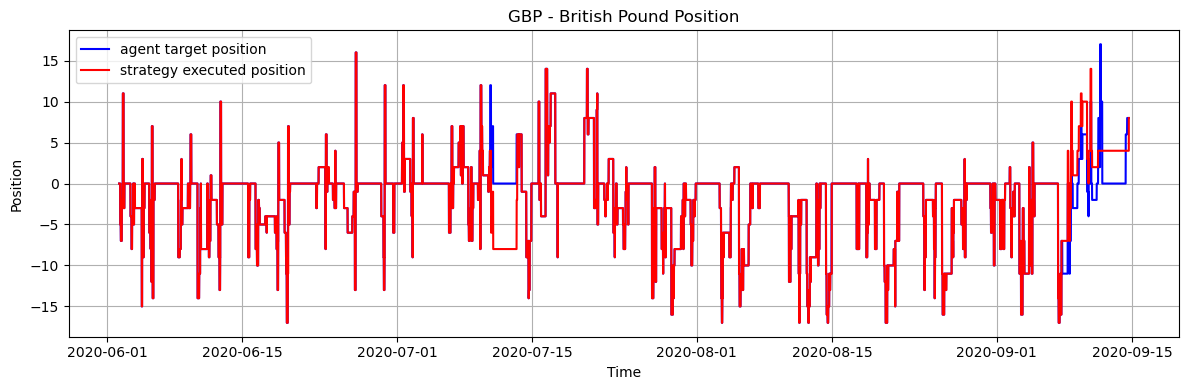


===== GBP - British Pound Summary =====
Final agent PnL:     92.3600000000024
Final strategy PnL:  73.12000000000262
Final PnL diff:      -19.23999999999978
Final PnL improve    -20.83%

Execution state counts:
execution_state
successful           422
delayed_execution     17
forced_close          10
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution      19.705882            19.705882
forced_close          337.300000           337.300000
successful              1.000000             1.000000


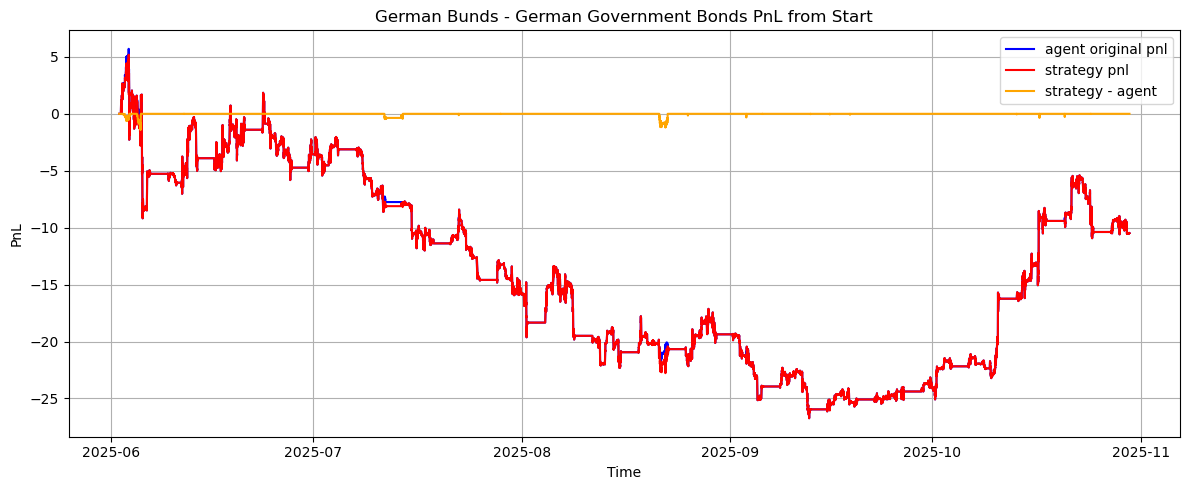

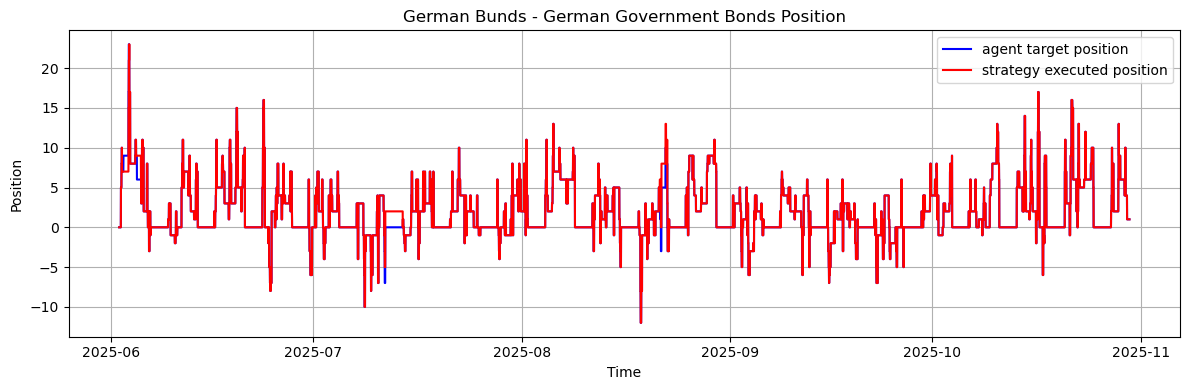


===== German Bunds - German Government Bonds Summary =====
Final agent PnL:     -10.479999999999649
Final strategy PnL:  -10.479999999999649
Final PnL diff:      0.0
Final PnL improve    -0.0%

Execution state counts:
execution_state
successful           595
delayed_execution     18
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution      54.722222            54.722222
successful              1.000000             1.000000


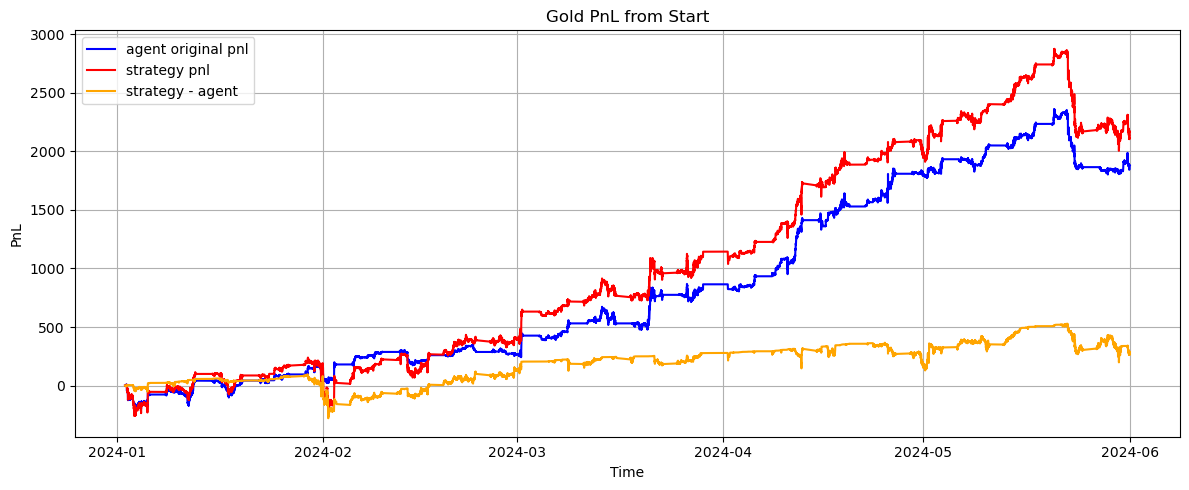

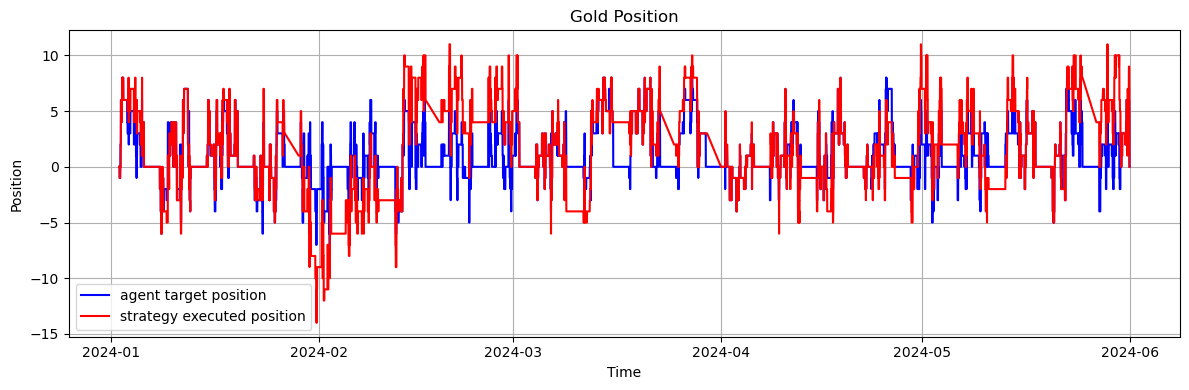


===== Gold Summary =====
Final agent PnL:     1882.00000000002
Final strategy PnL:  2163.30000000002
Final PnL diff:      281.3000000000002
Final PnL improve    14.95%

Execution state counts:
execution_state
successful           1138
delayed_execution     134
forced_close            4
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution     239.761194            60.358209
forced_close          644.000000           161.500000
successful              1.166081             1.000000


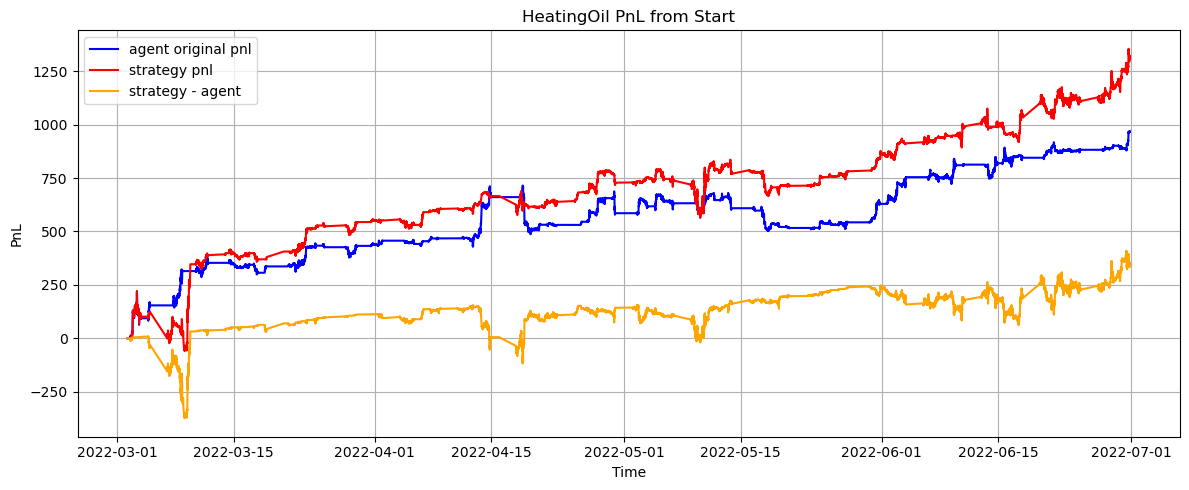

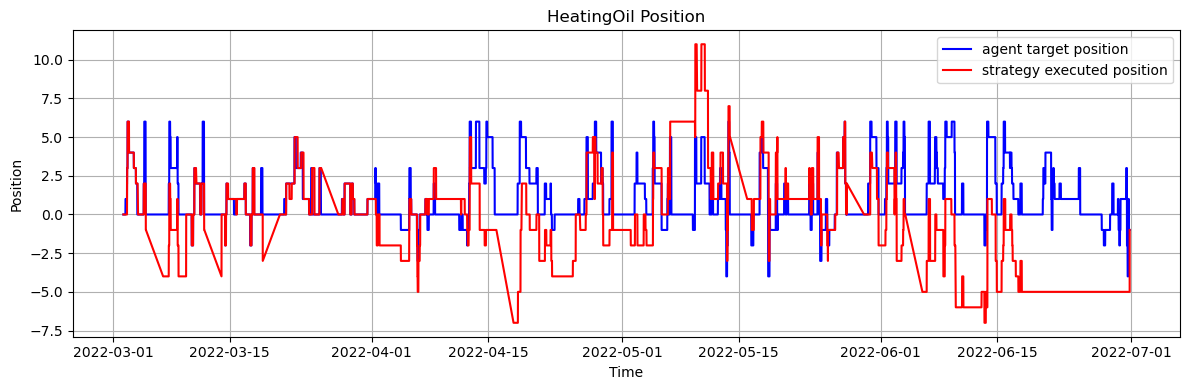


===== HeatingOil Summary =====
Final agent PnL:     966.8200000000004
Final strategy PnL:  1314.5099999999993
Final PnL diff:      347.6899999999989
Final PnL improve    35.96%

Execution state counts:
execution_state
successful           167
delayed_execution     88
forced_close          35
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution     274.431818            23.386364
forced_close         2042.571429           170.457143
successful              3.730539             1.000000


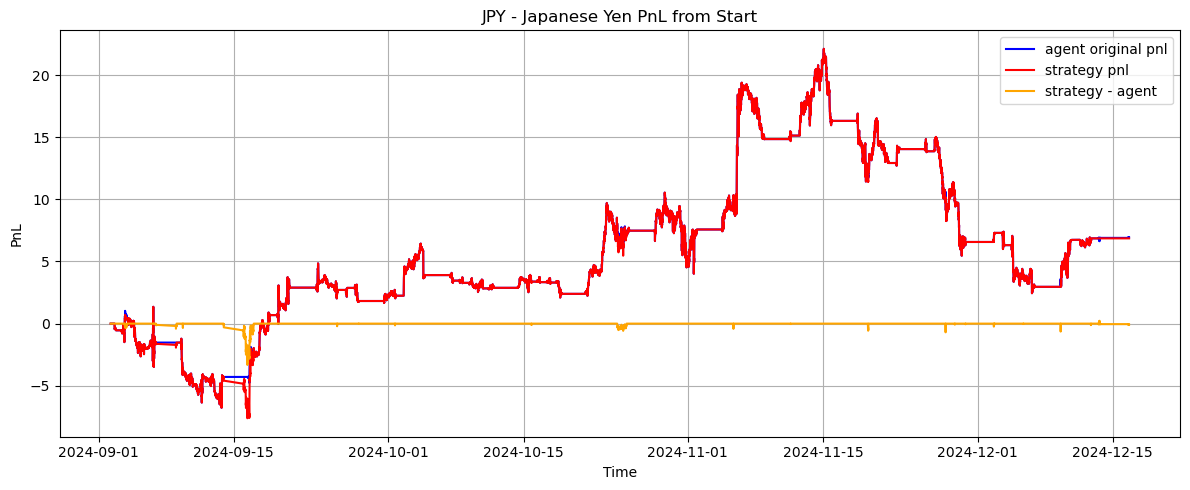

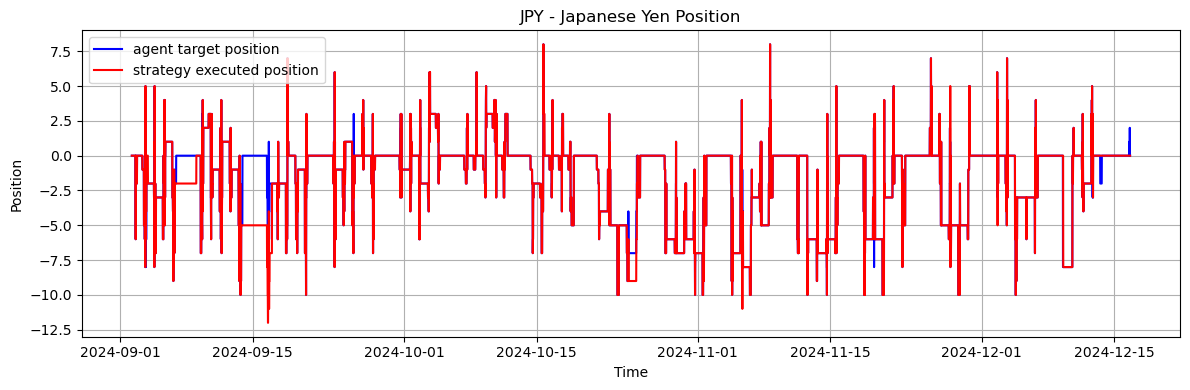


===== JPY - Japanese Yen Summary =====
Final agent PnL:     6.935000000000102
Final strategy PnL:  6.860000000000326
Final PnL diff:      -0.07499999999977547
Final PnL improve    -1.08%

Execution state counts:
execution_state
successful           734
delayed_execution     22
forced_close           6
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution           34.5                 34.5
forced_close               110.0                110.0
successful                   1.0                  1.0


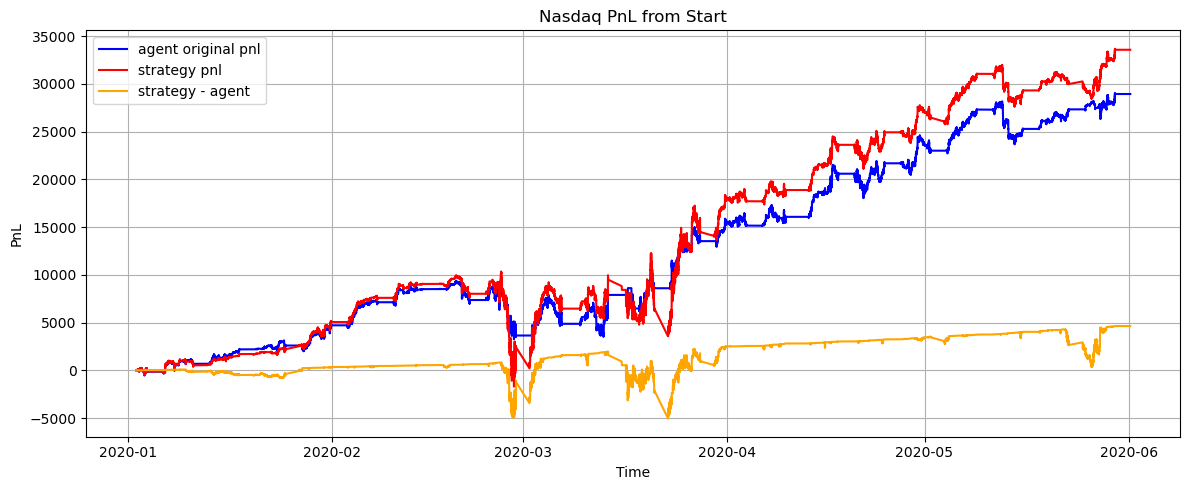

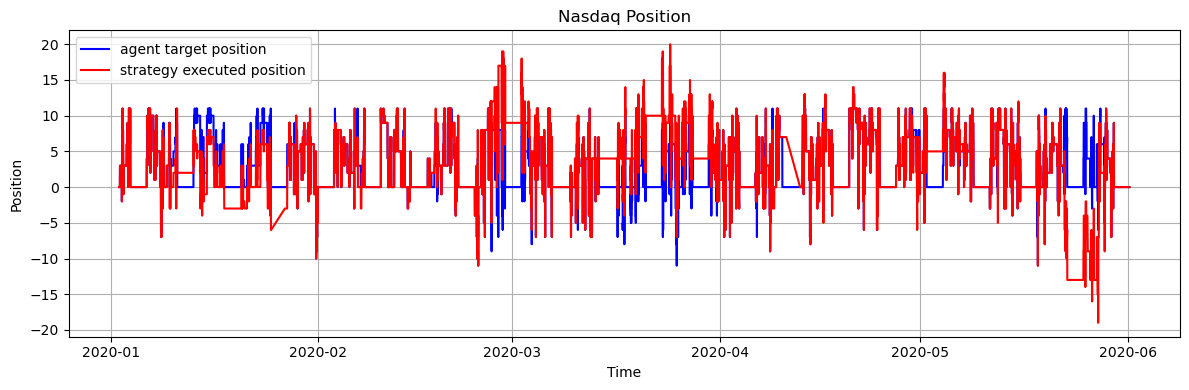


===== Nasdaq Summary =====
Final agent PnL:     28950.25
Final strategy PnL:  33585.75
Final PnL diff:      4635.5
Final PnL improve    16.01%

Execution state counts:
execution_state
successful           2042
delayed_execution     122
Name: count, dtype: int64

Average delay by execution state:
                   delay_5m_bars  delay_tau_intervals
execution_state                                      
delayed_execution     107.696721            54.155738
successful              1.018119             1.000000


In [11]:
raw_data_path=RAW_DATA_DIR
futures_path=DATA_DIR/'futures_right'
agent_path=DATA_DIR/'agent_right'
dict_output_path=DATA_DIR/'result_dict'

markets=sorted([p.name for p in raw_data_path.iterdir() if p.is_dir()])


tick_size = 0.25
tau_fill_prob={
    'EuroStoxx': [60,0.5],
    'GBP - British Pound': [5,0.9],
    'German Bunds - German Government Bonds': [5,0.9],
    'Gold':[20,0.8],
    'HeatingOil':[60,0.5],
    'JPY - Japanese Yen': [5,0.9],
    'Nasdaq':[10,0.9]
}

for market in markets:
    tau, fill_prob=tau_fill_prob[market]
    data1=pd.read_parquet(futures_path/'minute_1'/f'{market}.parquet').reset_index(drop=True)
    data1_prep=pd.read_parquet(futures_path/'minute_1'/f'{market}_prep.parquet').reset_index(drop=True)
    data5=pd.read_parquet(futures_path/'minute_5'/f'{market}.parquet').reset_index(drop=True)
    data5_prep=pd.read_parquet(futures_path/'minute_5'/f'{market}_prep.parquet').reset_index(drop=True)
    agent_data=pd.read_parquet(agent_path/f'{market}.parquet').reset_index(drop=True)
    trading_data=data5[['time','open','high','low','close','volume']].merge(agent_data[['time','price','position']],on='time')


    pnl_df, trade_detail_df = regime_fixed(
        trading_data=trading_data,
        data1=data1,
        data5=data5,
        prep_data1=data1_prep,
        prep_data5=data5_prep,
        tau=tau,
        fill_prob=fill_prob,
        tick_size=tick_size,

        vol_ema_span=100,
        price_short_span=20,
        price_long_span=100,

        max_k=10,
        min_obs_per_regime=25,
        n_vol_regimes=3,
        n_cross_regimes=3,
        
    )
    
    # --------------------------------------------------------
    # Plot PnL
    # --------------------------------------------------------

    pnl_plot = pnl_df.copy()
    pnl_plot["agent_pnl_from_start"] = (pnl_plot["agent_pnl"] - pnl_plot["agent_pnl"].iloc[0])
    pnl_plot["strategy_pnl_from_start"] = (pnl_plot["strategy_pnl"] - pnl_plot["strategy_pnl"].iloc[0])
    pnl_plot["pnl_diff_from_start"] = (pnl_plot["pnl_diff"] - pnl_plot["pnl_diff"].iloc[0])

    plt.figure(figsize=(12, 5))
    plt.plot(pnl_plot["time"],pnl_plot["agent_pnl_from_start"],label="agent original pnl",color='blue')
    plt.plot(pnl_plot["time"],pnl_plot["strategy_pnl_from_start"],label="strategy pnl",color='red')
    plt.plot(pnl_plot["time"],pnl_plot["pnl_diff_from_start"],label="strategy - agent",color='orange')
    plt.title(f"{market} PnL from Start")
    plt.xlabel("Time")
    plt.ylabel("PnL")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Plot position
    # --------------------------------------------------------

    plt.figure(figsize=(12, 4))
    plt.plot(pnl_df["time"],pnl_df["agent_position"],label="agent target position",color='blue')
    plt.plot(pnl_df["time"],pnl_df["strategy_position"],label="strategy executed position",color='red')
    plt.title(f"{market} Position")
    plt.xlabel("Time")
    plt.ylabel("Position")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Basic execution summary
    # --------------------------------------------------------

    print(f"\n===== {market} Summary =====")
    print("Final agent PnL:    ", pnl_df["agent_pnl"].iloc[-1])
    print("Final strategy PnL: ", pnl_df["strategy_pnl"].iloc[-1])
    print("Final PnL diff:     ", pnl_df["pnl_diff"].iloc[-1])
    print("Final PnL improve   ", f'{round(pnl_df["pnl_diff"].iloc[-1]/pnl_df["agent_pnl"].iloc[-1]*100,2)}%')

    print("\nExecution state counts:")
    print(trade_detail_df["execution_state"].value_counts(dropna=False))

    print("\nAverage delay by execution state:")
    print(trade_detail_df.groupby("execution_state")[["delay_5m_bars", "delay_tau_intervals"]].mean())